In [29]:
import numpy as np
import pandas as pd
import seaborn as sns

path = r"C:\Users\alfre\documentos_ssd\UNAM\Artículos\libro\data\Customer_Data.csv"
df = pd.read_csv(path)

In [30]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [31]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

<Axes: xlabel='PURCHASES', ylabel='CASH_ADVANCE'>

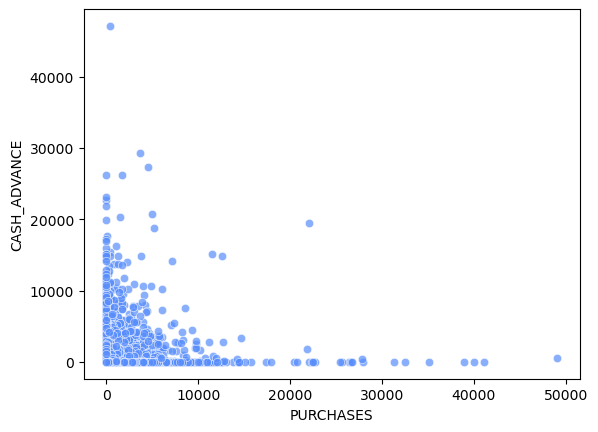

In [32]:
sns.scatterplot(df, x = 'PURCHASES', y = 'CASH_ADVANCE', alpha = 0.7)

C:\Users\alfre\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
C:\Users\alfre\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


<Axes: xlabel='PURCHASES', ylabel='CASH_ADVANCE'>

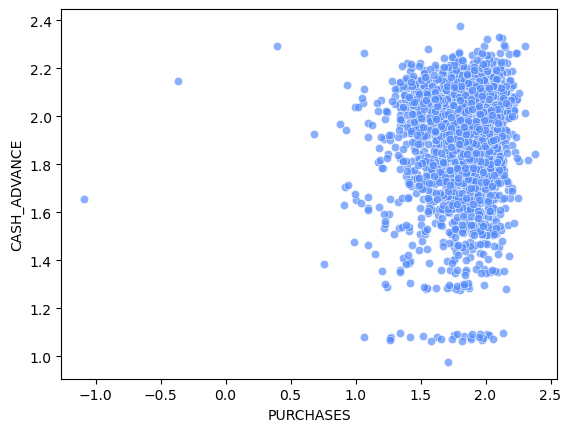

In [34]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = np.log(df[numeric_cols])

sns.scatterplot(df, x = 'PURCHASES', y = 'CASH_ADVANCE', alpha = 0.7)

In [87]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

path = r"C:\Users\alfre\documentos_ssd\UNAM\Artículos\libro\data\Customer_Data.csv"
df = pd.read_csv(path)

# Configuramos el scaler para que devuelva un pandas DataFrame
scaler = MinMaxScaler().set_output(transform="pandas")

numeric_cols = df.select_dtypes(include=[np.number]).columns
df_num = df[numeric_cols]

# Ahora fit_transform devuelve directamente un DataFrame con nombres de columnas e índice
df_scaled = scaler.fit_transform(df_num)

df_scaled[['PURCHASES','CASH_ADVANCE']].describe()


,PURCHASES,CASH_ADVANCE
count,8950.00000,8950.00000
mean,0.02046,0.02077
std,0.04357,0.04449
min,0.00000,0.00000
25%,0.00081,0.00000
50%,0.00737,0.00000
75%,0.02264,0.02363
max,1.00000,1.00000


In [107]:
from sklearn.decomposition import PCA

df_scaled = df_scaled.dropna()

pca = PCA(n_components=2).set_output(transform="pandas")
df_pca = pca.fit_transform(df_scaled)

In [110]:
df_pca

,pca0,pca1
0,-0.49205,-0.10699
1,-0.62069,-0.03014
2,0.29158,0.92292
4,-0.56782,0.02303
5,0.18814,-0.24946
...,...,...
8943,-0.56305,-0.05626
8945,0.64165,-0.43986
8947,0.35722,-0.39702
8948,-0.65011,-0.17050


<Axes: xlabel='pca0', ylabel='pca1'>

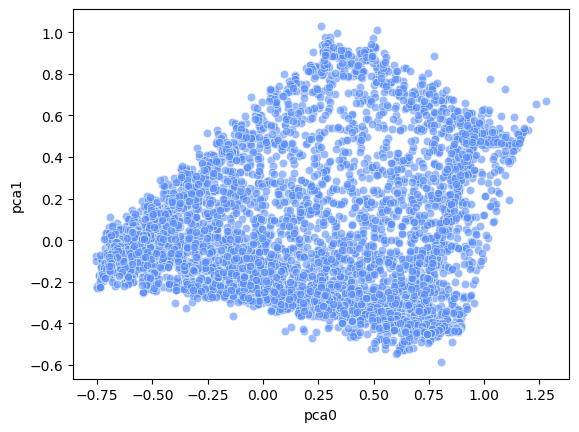

In [113]:
sns.scatterplot(data = df_pca, x = 'pca0', y = 'pca1', alpha = 0.6)

## KNN - Clasificacion no supervisada de la cartera

In [123]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

kmeans = KMeans(n_clusters=7).fit(df_pca)

df_pca['label'] = kmeans.predict(df_pca)


<Axes: xlabel='pca0', ylabel='pca1'>

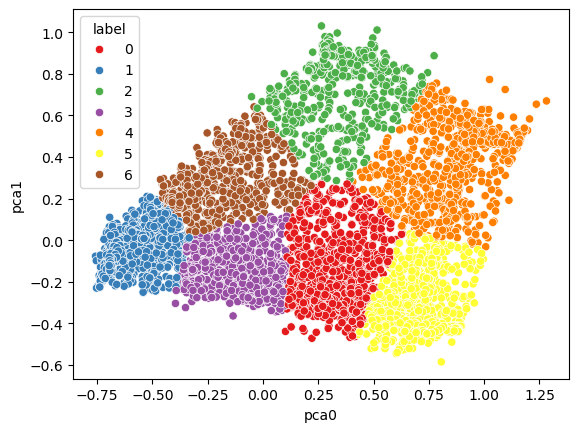

In [127]:
sns.scatterplot(df_pca, x ='pca0', y = 'pca1', hue = 'label', palette= 'Set1')

ERROR! Session/line number was not unique in database. History logging moved to new session 16


<Axes: xlabel='label', ylabel='pca0'>

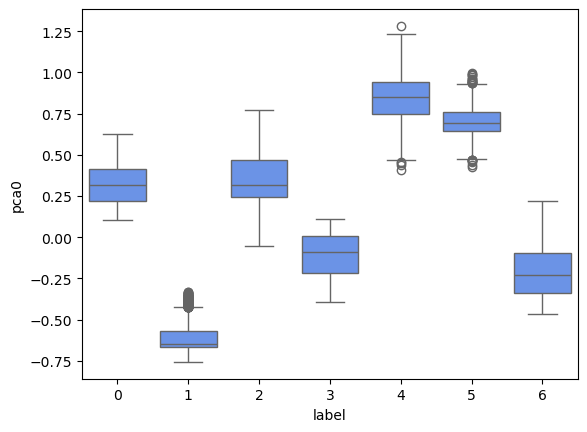

In [133]:
sns.boxplot(data = df_pca, x= 'label', y = 'pca0')

<Axes: xlabel='label', ylabel='pca1'>

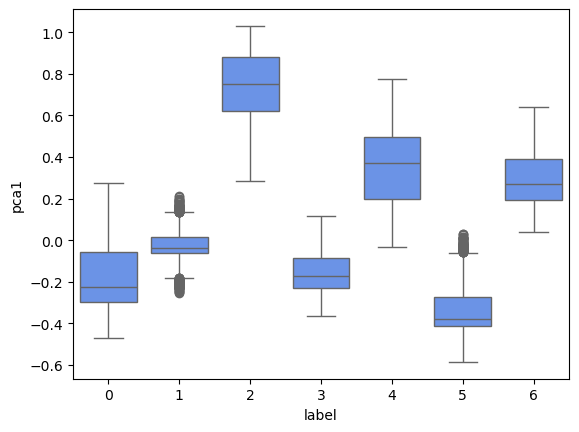

In [134]:
sns.boxplot(data = df_pca, x= 'label', y = 'pca1')